# Analisis Sentimen Ulasan Produk Tokopedia 2025

Notebook mencakup pengambilan data, eksplorasi, preprocessing teks bahasa Indonesia,
pelatihan Logistic Regression, penanganan ketidakseimbangan kelas, serta eksperimen IndoBERT.


## 1. Persiapan lingkungan

In [59]:
%pip install -q kagglehub Sastrawi wordcloud

In [60]:
import random
import re
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from wordcloud import WordCloud

RANDOM_STATE = 42
LABELS = ["negative", "neutral", "positive"]
random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")


## 2. Memuat dataset

In [61]:
dataset_dir = Path(kagglehub.dataset_download("salmanabdu/tokopedia-product-reviews-2025"))
csv_path = next(dataset_dir.glob("*.csv"))
df = pd.read_csv(csv_path)

print(f"Dataset: {csv_path.name}")
print(f"Ukuran: {df.shape[0]:,} baris × {df.shape[1]} kolom")
display(df.head())

Using Colab cache for faster access to the 'tokopedia-product-reviews-2025' dataset.
Dataset: tokopedia_product_reviews_2025.csv
Ukuran: 65,543 baris × 13 kolom


,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,baru sekali ini terima brg dr belanja online d...,2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurut...,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
2,Telornya sudah sampai di rumah dengan kemasan ...,2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
3,Telor sudah diterima dengan baik dan tidak ada...,2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik...",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive


## 3. Eksplorasi data (EDA)


In [62]:
df.info()
display(df.describe(include="all"))
display(df.isna().sum().rename("missing_values"))
display(df["rating"].value_counts().sort_index().rename("jumlah"))
display(df["sentiment_label"].value_counts().rename("jumlah"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65543 entries, 0 to 65542
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_text       65543 non-null  object
 1   review_date       65543 non-null  object
 2   review_id         65543 non-null  int64 
 3   product_name      65543 non-null  object
 4   product_category  65543 non-null  object
 5   product_variant   26749 non-null  object
 6   product_price     65543 non-null  int64 
 7   product_url       65543 non-null  object
 8   product_id        65543 non-null  int64 
 9   rating            65543 non-null  int64 
 10  sold_count        65543 non-null  int64 
 11  shop_id           65543 non-null  int64 
 12  sentiment_label   65543 non-null  object
dtypes: int64(6), object(7)
memory usage: 6.5+ MB


,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
count,65543,65543,6.554300e+04,65543,65543,26749,6.554300e+04,65543,6.554300e+04,65543.000000,65543.000000,6.554300e+04,65543
unique,58068,2845,NaN,5418,6,5511,NaN,5521,NaN,NaN,NaN,NaN,3
top,Bagus,2025-10-15,NaN,Chosamon Mid Top Original Sepatu Sneakers Olah...,Makanan & Minuman,Default,NaN,https://www.tokopedia.com/sasaofficial/sasa-te...,NaN,NaN,NaN,NaN,positive
freq,323,83,NaN,80,17859,1733,NaN,20,NaN,NaN,NaN,NaN,63943
mean,NaN,NaN,9.814143e+08,NaN,NaN,NaN,5.421295e+05,NaN,2.447482e+10,4.893764,1954.923897,7.615674e+16,NaN
std,NaN,NaN,4.193324e+08,NaN,NaN,NaN,2.365557e+06,NaN,3.870717e+10,0.492495,18244.026827,7.516573e+17,NaN
min,NaN,NaN,1.027202e+07,NaN,NaN,NaN,1.000000e+02,NaN,4.298375e+06,1.000000,6.000000,6.050000e+02,NaN
25%,NaN,NaN,7.182240e+08,NaN,NaN,NaN,2.990000e+04,NaN,1.446882e+09,5.000000,100.000000,2.298522e+06,NaN
50%,NaN,NaN,9.740048e+08,NaN,NaN,NaN,8.000000e+04,NaN,4.769575e+09,5.000000,500.000000,5.801280e+06,NaN
75%,NaN,NaN,1.145967e+09,NaN,NaN,NaN,2.146870e+05,NaN,1.534605e+10,5.000000,1000.000000,9.061811e+06,NaN


,missing_values
review_text,0
review_date,0
review_id,0
product_name,0
product_category,0
product_variant,38794
product_price,0
product_url,0
product_id,0
rating,0


,jumlah
rating,
1,547
2,251
3,802
4,2418
5,61525


,jumlah
sentiment_label,
positive,63943
neutral,802
negative,798


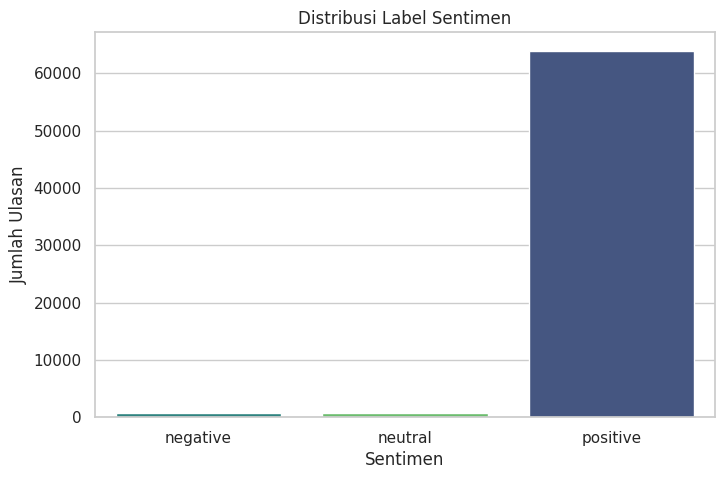

In [63]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="sentiment_label",
    order=LABELS,
    hue="sentiment_label",
    palette="viridis",
    legend=False,
)
plt.title("Distribusi Label Sentimen")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")
plt.show()

## 4. Preprocessing teks

In [64]:
stopword_remover = StopWordRemoverFactory().create_stop_word_remover()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return stopword_remover.remove(text)

sample_text = df["review_text"].dropna().iloc[0]
print("Sebelum:", sample_text)
print("Sesudah:", clean_text(sample_text))

Sebelum: baru sekali ini terima brg dr belanja online dg packing super rapih dan aman. semula ragu, bagaimana mungkin mmbeli terlur ayam mentah , sec online. tp ternyata packing liar biasa. rapi, aman. Kerem seller
Sesudah: baru sekali terima brg dr belanja online dg packing super rapih aman semula ragu bagaimana mungkin mmbeli terlur ayam mentah sec online tp ternyata packing liar biasa rapi aman kerem seller


In [65]:
stemmer = StemmerFactory().create_stemmer()

def clean_text_advanced(text):
    return stemmer.stem(clean_text(text))

print(f"Sebelum stemming: {sample_text[:50]}...")
print(f"Sesudah stemming: {clean_text_advanced(sample_text)}")


Sebelum stemming: baru sekali ini terima brg dr belanja online dg pa...
Sesudah stemming: baru sekali terima brg dr belanja online dg packing super rapih aman mula ragu bagaimana mungkin mmbeli terlur ayam mentah sec online tp nyata packing liar biasa rapi aman rem seller


### 4.1 Normalisasi slang dan emotikon

Bagian ini menambahkan kamus slang dan konversi emotikon untuk meningkatkan kualitas fitur teks.


In [66]:
slang_dict = {
    "bgt": "banget", "bgtt": "banget", "jd": "jadi", "ga": "tidak",
    "gak": "tidak", "tdk": "tidak", "sdh": "sudah", "udah": "sudah",
    "brg": "barang", "krn": "karena", "cpt": "cepat", "jg": "juga",
    "tp": "tapi", "kalo": "kalau", "dgn": "dengan", "dr": "dari",
    "ori": "original", "mksh": "terima kasih", "tks": "terima kasih"
}

emoticon_map = {
    "😊": " senang ", "🙂": " senang ", "😄": " senang ", "😍": " suka ",
    "👍": " bagus ", "👌": " bagus ", "⭐": " bintang ",
    "😞": " kecewa ", "😟": " kecewa ", "😠": " marah ", "😡": " marah ",
    "👎": " buruk ", "😢": " sedih ", "😭": " sedih "
}

def normalize_slang(text):
    words = text.split()
    return " ".join([slang_dict.get(w, w) for w in words])

def convert_emoticons(text):
    for emo, replacement in emoticon_map.items():
        text = text.replace(emo, replacement)
    return text

def clean_text_final(text):
    # Konversi emotikon sebelum regex menghapusnya
    text = convert_emoticons(str(text))
    text = clean_text(text)
    text = normalize_slang(text)
    return stemmer.stem(text)

test_slang = "barangnya bgt bagus, tp pengiriman agak lama jd kecewa 😊"
print(f"Original: {test_slang}")
print(f"Processed: {clean_text_final(test_slang)}")

Original: barangnya bgt bagus, tp pengiriman agak lama jd kecewa 😊
Processed: barang banget bagus tapi kirim lama jadi kecewa senang


## 5. Pelatihan model baseline

In [67]:
n_samples = 700
balanced_parts = []

for label in LABELS:
    group = df[df["sentiment_label"] == label]
    balanced_parts.append(
        group.sample(
            n=n_samples,
            replace=len(group) < n_samples,
            random_state=RANDOM_STATE,
        )
    )

df_balanced = pd.concat(balanced_parts, ignore_index=True)
df_balanced["clean_text"] = df_balanced["review_text"].apply(clean_text)

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced["clean_text"],
    df_balanced["sentiment_label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_balanced["sentiment_label"],
)

baseline_tfidf = TfidfVectorizer(max_features=2_000)
X_train_tfidf = baseline_tfidf.fit_transform(X_train)
X_test_tfidf = baseline_tfidf.transform(X_test)

baseline_model = LogisticRegression(max_iter=1_000, random_state=RANDOM_STATE)
baseline_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## 6. Evaluasi model baseline

              precision    recall  f1-score   support

    negative       0.61      0.61      0.61       140
     neutral       0.54      0.53      0.53       140
    positive       0.82      0.83      0.82       140

    accuracy                           0.66       420
   macro avg       0.66      0.66      0.66       420
weighted avg       0.66      0.66      0.66       420



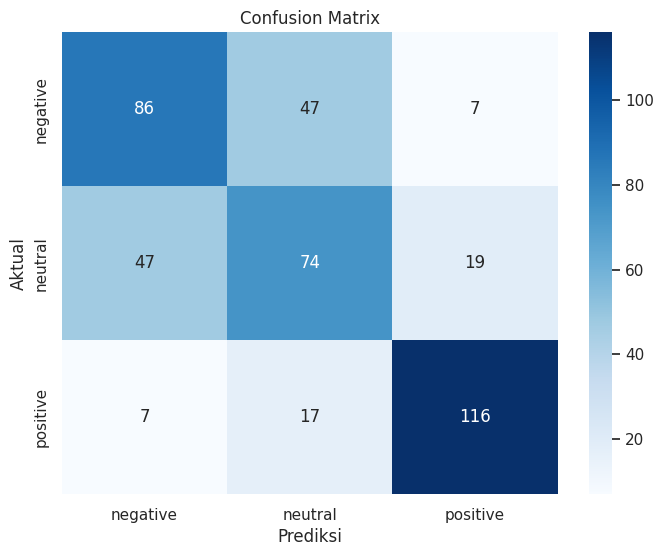

In [68]:
y_pred = baseline_model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, labels=LABELS, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=LABELS)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()

## 7. Optimasi hyperparameter

In [69]:
df_balanced["clean_text"] = df_balanced["review_text"].apply(clean_text_advanced)

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced["clean_text"],
    df_balanced["sentiment_label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_balanced["sentiment_label"],
)

pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer()),
        ("clf", LogisticRegression(max_iter=1_000, random_state=RANDOM_STATE)),
    ]
)
param_grid = {
    "tfidf__max_features": [1_000, 2_000, 3_000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [0.1, 1, 10],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring="f1_macro",
)
grid_search.fit(X_train, y_train)

print(f"Parameter terbaik: {grid_search.best_params_}")
print(f"Skor CV terbaik: {grid_search.best_score_:.4f}")


Parameter terbaik: {'clf__C': 1, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2)}
Skor CV terbaik: 0.6559


In [70]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("Hasil setelah tuning")
print(
    classification_report(
        y_test,
        y_pred_tuned,
        labels=LABELS,
        zero_division=0,
    )
)


Hasil setelah tuning
              precision    recall  f1-score   support

    negative       0.60      0.62      0.61       140
     neutral       0.54      0.51      0.53       140
    positive       0.80      0.81      0.81       140

    accuracy                           0.65       420
   macro avg       0.65      0.65      0.65       420
weighted avg       0.65      0.65      0.65       420



## 8. Visualisasi kata dominan

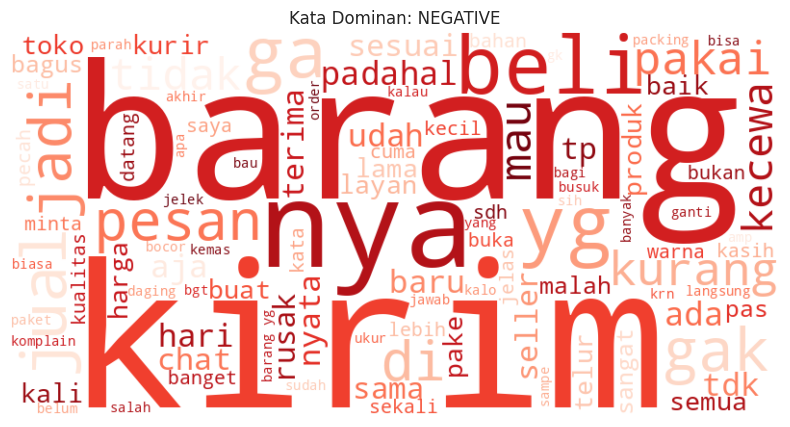

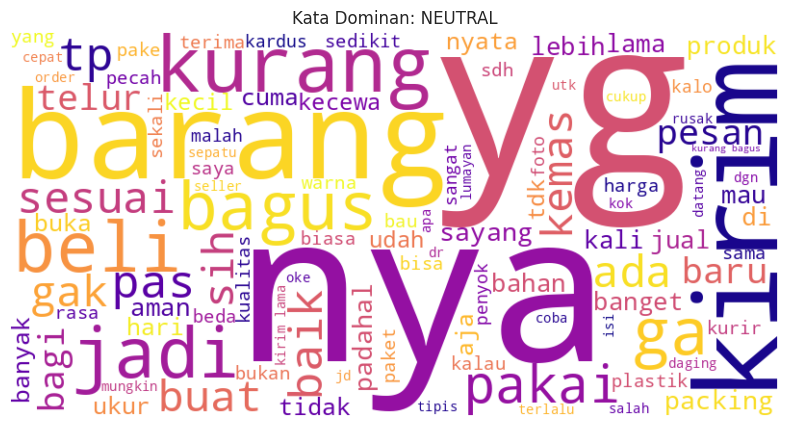

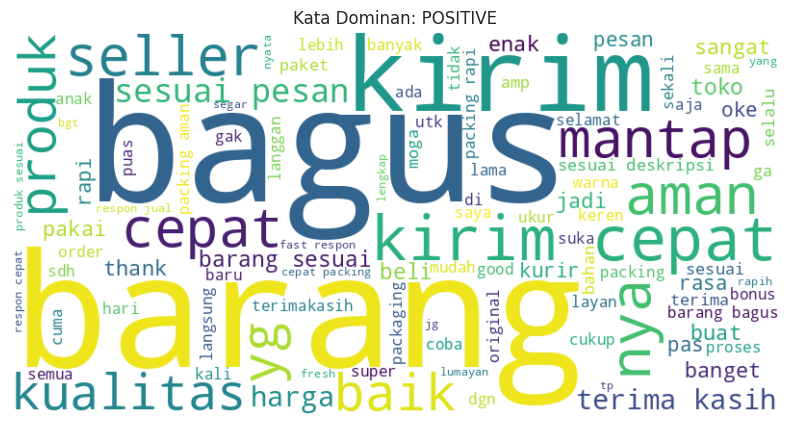

In [71]:
def show_wordcloud(sentiment, colormap):
    text = " ".join(
        df_balanced.loc[
            df_balanced["sentiment_label"] == sentiment, "clean_text"
        ]
    )
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap=colormap,
        max_words=100,
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Kata Dominan: {sentiment.upper()}")
    plt.show()

for sentiment, colormap in zip(LABELS, ["Reds", "plasma", "viridis"]):
    show_wordcloud(sentiment, colormap)

## 9. Prediksi ulasan baru

In [72]:
def prediksi_sentimen(teks):
    teks_bersih = clean_text(teks)
    vektor = baseline_tfidf.transform([teks_bersih])
    return baseline_model.predict(vektor)[0]


contoh_ulasan = [
    "Barangnya rusak saat sampai",
    "Bagus banget, pengiriman cepat",
    "Biasa saja, lumayan",
]

for ulasan in contoh_ulasan:
    print(f"{ulasan!r}: {prediksi_sentimen(ulasan)}")

'Barangnya rusak saat sampai': negative
'Bagus banget, pengiriman cepat': positive
'Biasa saja, lumayan': neutral


## 10. Penanganan ketidakseimbangan kelas

### 10.1 Augmentasi teks

Penggantian sinonim sederhana menambah variasi pada kelas minoritas.


In [73]:

synonym_dict = {
    "bagus": ["baik", "oke", "mantap", "keren"],
    "buruk": ["jelek", "kurang", "parah"],
    "kecewa": ["kesal", "nyesel", "sedih"],
    "cepat": ["kilat", "gegas", "ekspres"],
    "lama": ["lambat", "lelet", "telat"]
}

def augment_text(text):
    words = text.split()
    new_words = words.copy()
    for i, word in enumerate(words):
        if word in synonym_dict:
            if random.random() > 0.5:
                new_words[i] = random.choice(synonym_dict[word])
    return " ".join(new_words)

neg_samples = df[df['sentiment_label'] == 'negative']['review_text'].iloc[:2]
for txt in neg_samples:
    print(f"Original: {txt[:50]}...")
    print(f"Augmented: {augment_text(txt)[:50]}...")

Original: telor busuk semua 20 butir gak ada yg bagus 1 pun....
Augmented: telor busuk semua 20 butir gak ada yg baik 1 pun.....
Original: Kualitas barang tidak rata, ada yg kecil kurang da...
Augmented: Kualitas barang tidak rata, ada yg kecil kurang da...


### 10.2 SMOTE

`imbalanced-learn` menyeimbangkan fitur TF-IDF secara sintetis.


In [74]:
%pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE

df_smote = df.sample(n=min(5_000, len(df)), random_state=RANDOM_STATE).copy()
df_smote['clean_text'] = df_smote['review_text'].apply(clean_text_final)

tfidf_smote = TfidfVectorizer(max_features=2000)
X_tfidf = tfidf_smote.fit_transform(df_smote['clean_text'])
y = df_smote['sentiment_label']

smote = SMOTE(random_state=RANDOM_STATE)
X_resampled, y_resampled = smote.fit_resample(X_tfidf, y)

print("Jumlah data sebelum SMOTE:", y.value_counts().to_dict())
print("Jumlah data setelah SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

Jumlah data sebelum SMOTE: {'positive': 4863, 'neutral': 70, 'negative': 67}
Jumlah data setelah SMOTE: {'positive': 4863, 'negative': 4863, 'neutral': 4863}


In [75]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=RANDOM_STATE
)

smote_model = LogisticRegression(max_iter=1000)
smote_model.fit(X_train_s, y_train_s)

y_pred_s = smote_model.predict(X_test_s)
print("Laporan klasifikasi dengan SMOTE:")
print(classification_report(y_test_s, y_pred_s))

Laporan klasifikasi dengan SMOTE:
              precision    recall  f1-score   support

    negative       0.99      1.00      0.99      1001
     neutral       0.96      0.98      0.97       916
    positive       0.99      0.96      0.97      1001

    accuracy                           0.98      2918
   macro avg       0.98      0.98      0.98      2918
weighted avg       0.98      0.98      0.98      2918



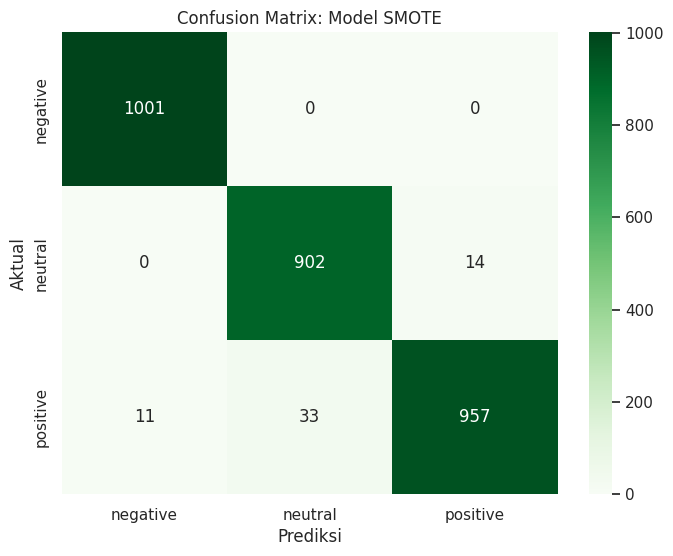

In [76]:
cm_smote = confusion_matrix(y_test_s, y_pred_s, labels=LABELS)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_smote,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=LABELS,
    yticklabels=LABELS,
)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix: Model SMOTE")
plt.show()


### 10.3 Class weighting

Eksperimen ini memakai subset data lebih besar dan `class_weight="balanced"` untuk
menangani ketidakseimbangan kelas tanpa undersampling.


In [77]:
df_large = df.sample(n=min(10_000, len(df)), random_state=RANDOM_STATE).copy()
df_large["clean_text"] = df_large["review_text"].apply(clean_text)

X_train_large, X_test_large, y_train_large, y_test_large = train_test_split(
    df_large["clean_text"],
    df_large["sentiment_label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_large["sentiment_label"],
)

weighted_model = Pipeline(
    [
        ("tfidf", TfidfVectorizer(max_features=3_000)),
        (
            "clf",
            LogisticRegression(
                max_iter=1_000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
weighted_model.fit(X_train_large, y_train_large)

y_pred_large = weighted_model.predict(X_test_large)
print("Laporan klasifikasi dengan class weighting:")
print(
    classification_report(
        y_test_large,
        y_pred_large,
        labels=LABELS,
        zero_division=0,
    )
)

Laporan klasifikasi dengan class weighting:
              precision    recall  f1-score   support

    negative       0.19      0.36      0.25        25
     neutral       0.09      0.27      0.13        26
    positive       0.99      0.95      0.97      1949

    accuracy                           0.93      2000
   macro avg       0.42      0.53      0.45      2000
weighted avg       0.97      0.93      0.95      2000



### 10.4 Strategi Peningkatan Kelas Neutral

Kita akan mencoba menggabungkan fitur panjang teks dan penyesuaian bobot probabilitas untuk menangkap sinyal 'neutral' yang lebih kuat.

In [88]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import FeatureUnion
import numpy as np

# 1. Menyeimbangkan dataset pelatihan secara manual
n_balanced = 500
balanced_train = pd.concat([
    df[df['sentiment_label'] == label].sample(n=min(n_balanced, len(df[df['sentiment_label'] == label])), random_state=RANDOM_STATE)
    for label in LABELS
])

X_train_bal = balanced_train['review_text'].apply(clean_text)
y_train_bal = balanced_train['sentiment_label']

# 2. Re-fit pipeline dengan data yang benar-benar seimbang
class TextStats(BaseEstimator, TransformerMixin):
    def fit(self, x, y=None): return self
    def transform(self, posts):
        return np.array([len(str(text)) for text in posts]).reshape(-1, 1)

enhanced_pipeline = Pipeline([
    ('features', FeatureUnion([
        ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1,2))),
        ('stats', TextStats())
    ])),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
])

enhanced_pipeline.fit(X_train_bal, y_train_bal)

# 3. Menggunakan Threshold Tuning untuk Neutral
y_probs = enhanced_pipeline.predict_proba(X_test_large)
# Beri 'bonus' probabilitas 0.2 untuk kelas neutral (indeks 1)
y_probs[:, 1] += 0.2
y_pred_tuned = [LABELS[i] for i in np.argmax(y_probs, axis=1)]

print("Laporan Klasifikasi (Balanced Training + Threshold Tuning):")
print(classification_report(y_test_large, y_pred_tuned, labels=LABELS))

Laporan Klasifikasi (Balanced Training + Threshold Tuning):
              precision    recall  f1-score   support

    negative       0.24      0.72      0.36        25
     neutral       0.05      0.96      0.09        26
    positive       1.00      0.70      0.83      1949

    accuracy                           0.71      2000
   macro avg       0.43      0.80      0.43      2000
weighted avg       0.98      0.71      0.81      2000



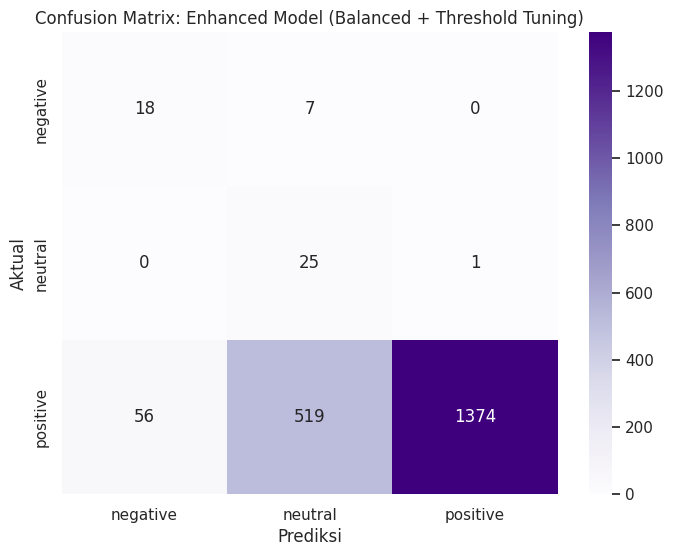

In [89]:
cm_enhanced = confusion_matrix(y_test_large, y_pred_tuned, labels=LABELS)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_enhanced,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=LABELS,
    yticklabels=LABELS,
)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix: Enhanced Model (Balanced + Threshold Tuning)")
plt.show()

In [90]:
# Mencari indeks di mana aktualnya 'positive' tapi prediksinya 'neutral'
pos_as_neu_indices = [i for i, (true, pred) in enumerate(zip(y_test_large, y_pred_tuned))
                      if true == 'positive' and pred == 'neutral']

# Menampilkan 10 contoh ulasan tersebut
print(f"Total Positive predicted as Neutral: {len(pos_as_neu_indices)}")
print("-" * 30)

sample_errors = df_large.iloc[pos_as_neu_indices].head(10)
for i, row in sample_errors.iterrows():
    print(f"Ulasan: {row['review_text']}")
    print(f"Sentimen Asli: {row['sentiment_label']}")
    print("-" * 10)

Total Positive predicted as Neutral: 519
------------------------------
Ulasan: produk dreame selalu the best
Sentimen Asli: positive
----------
Ulasan: Produk Original Barang Sesuai Deskripsi Produk berfungsi dengan baik
Sentimen Asli: positive
----------
Ulasan: proses pengiriman cepat, kwalitas mantap
Sentimen Asli: positive
----------
Ulasan: Produk asli. Packing aman. Pengiriman cepat. Thx
Sentimen Asli: positive
----------
Ulasan: Mantaaaaaaaaaapppppppp
Sentimen Asli: positive
----------
Ulasan: Mantap. Dapat bonus pula yang paling kanan
Sentimen Asli: positive
----------
Ulasan: kuah tori paitan sih the best. life saver bgt di saat bayi lagi batpil. bnran enak bgt. daddy nya pun super suka. rasanya ngaldu kayak kuah ramen. bnr bnr next level. bakal sering nyetok di rumah buat anak anak.
Sentimen Asli: positive
----------
Ulasan: mantap...harga murah ,telurnya besar2, kemasan baik....sampai dengan selamat
Sentimen Asli: positive
----------
Ulasan: Sudah sering pakai dan beli. Ena

### 11.7 Menguji IndoBERT pada Kasus Salah Klasifikasi (Positive as Neutral)

Kita akan mengambil 519 ulasan yang salah diklasifikasikan oleh model Logistic Regression sebelumnya dan melihat bagaimana performa IndoBERT terhadap ulasan-ulasan tersebut.

In [91]:
# 1. Menyiapkan dataset dari sampel yang salah diklasifikasikan
misclassified_texts = df_large.iloc[pos_as_neu_indices]['review_text'].tolist()
misclassified_dataset = Dataset.from_dict({"review_text": misclassified_texts})

# 2. Tokenisasi
def tokenize_test(examples):
    return tokenizer(examples["review_text"], padding="max_length", truncation=True, max_length=128)

misclassified_tokenized = misclassified_dataset.map(tokenize_test, batched=True)

# 3. Prediksi menggunakan Trainer IndoBERT yang sudah ada
bert_predictions = trainer.predict(misclassified_tokenized)
y_pred_bert_indices = np.argmax(bert_predictions.predictions, axis=-1)
y_pred_bert_labels = [id2label[idx] for idx in y_pred_bert_indices]

# 4. Analisis Hasil
from collections import Counter
counts = Counter(y_pred_bert_labels)

print(f"Total sampel diuji: {len(misclassified_texts)}")
print(f"Hasil Prediksi IndoBERT:")
for label, count in counts.items():
    print(f"- {label}: {count} ({count/len(misclassified_texts):.2%})")

# Menampilkan beberapa contoh yang berhasil diperbaiki IndoBERT
print('\nContoh ulasan yang diperbaiki IndoBERT (sebelumnya dianggap Neutral):')
correct_idx = [i for i, label in enumerate(y_pred_bert_labels) if label == 'positive'][:5]
for idx in correct_idx:
    print(f"Ulasan: {misclassified_texts[idx]}")

Map:   0%|          | 0/519 [00:00<?, ? examples/s]

Total sampel diuji: 519
Hasil Prediksi IndoBERT:
- positive: 454 (87.48%)
- negative: 17 (3.28%)
- neutral: 48 (9.25%)

Contoh ulasan yang diperbaiki IndoBERT (sebelumnya dianggap Neutral):
Ulasan: produk dreame selalu the best
Ulasan: Produk Original Barang Sesuai Deskripsi Produk berfungsi dengan baik
Ulasan: proses pengiriman cepat, kwalitas mantap
Ulasan: Produk asli. Packing aman. Pengiriman cepat. Thx
Ulasan: Mantaaaaaaaaaapppppppp


## 11. Eksperimen IndoBERT

Bagian opsional ini memakai `indobenchmark/indobert-base-p2`. Jalankan dengan runtime
GPU agar fine-tuning lebih cepat.

In [78]:
%pip install -q transformers datasets torch

In [79]:
from glob import glob
import os

import numpy as np
import torch
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)

BERT_MODEL_NAME = "indobenchmark/indobert-base-p2"
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

label2id = {label: index for index, label in enumerate(LABELS)}
id2label = {index: label for index, label in enumerate(LABELS)}

bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
)


def tokenize_function(examples):
    return tokenizer(
        examples["review_text"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 11.1 Menyiapkan dataset

In [80]:
train_df, val_df = train_test_split(
    df_balanced,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_balanced["sentiment_label"],
)

train_dataset = Dataset.from_pandas(
    train_df[["review_text", "sentiment_label"]],
    preserve_index=False,
)
val_dataset = Dataset.from_pandas(
    val_df[["review_text", "sentiment_label"]],
    preserve_index=False,
)

train_dataset = train_dataset.map(
    lambda row: {"labels": label2id[row["sentiment_label"]]}
)
val_dataset = val_dataset.map(
    lambda row: {"labels": label2id[row["sentiment_label"]]}
)
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/1680 [00:00<?, ? examples/s]

Map:   0%|          | 0/420 [00:00<?, ? examples/s]

Map:   0%|          | 0/1680 [00:00<?, ? examples/s]

Map:   0%|          | 0/420 [00:00<?, ? examples/s]

### 11.2 Fine-tuning

Konfigurasi berikut melatih model selama tiga epoch dan menyimpan model terbaik.

In [81]:
def compute_metrics(prediction):
    labels = prediction.label_ids
    predictions = prediction.predictions.argmax(axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0,
    )
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1,
        "precision": precision,
        "recall": recall,
    }


training_args = TrainingArguments(
    output_dir="results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.646639,0.659694,0.697619,0.680361,0.725553,0.697619
2,0.564445,0.588455,0.726190,0.727650,0.732673,0.726190
3,0.333685,0.717361,0.733333,0.732542,0.738242,0.733333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=315, training_loss=0.5494793490758018, metrics={'train_runtime': 198.0131, 'train_samples_per_second': 25.453, 'train_steps_per_second': 1.591, 'total_flos': 331522906337280.0, 'train_loss': 0.5494793490758018, 'epoch': 3.0})

### 11.3 Evaluasi IndoBERT

In [82]:
bert_metrics = trainer.evaluate()
bert_metrics

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.333685,0.588455,3,0.726190,0.727650,0.732673,0.726190


{'eval_loss': 0.5884549617767334,
 'eval_accuracy': 0.7261904761904762,
 'eval_f1': 0.7276503707699303,
 'eval_precision': 0.7326732783324551,
 'eval_recall': 0.7261904761904762}

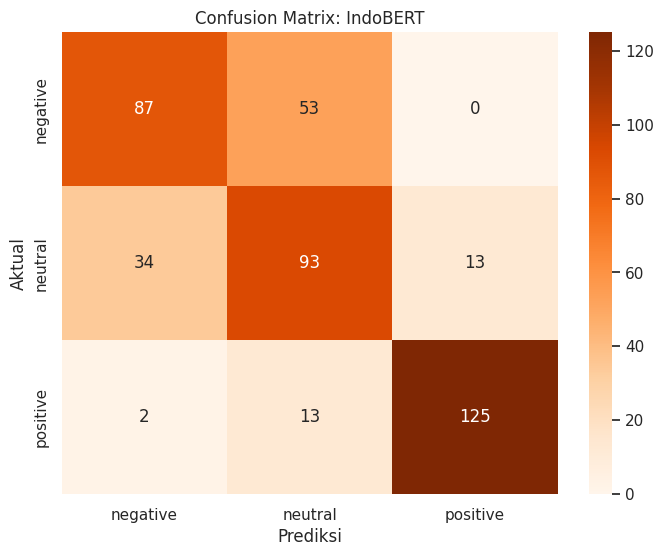

In [83]:
prediction_output = trainer.predict(val_dataset)
y_pred_bert = np.argmax(prediction_output.predictions, axis=-1)
y_true_bert = prediction_output.label_ids

cm_bert = confusion_matrix(
    y_true_bert,
    y_pred_bert,
    labels=range(len(LABELS)),
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_bert,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=LABELS,
    yticklabels=LABELS,
)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix: IndoBERT")
plt.show()


### 11.4 Analisis kesalahan

Lima ulasan berikut merupakan contoh prediksi IndoBERT yang keliru.


In [84]:
error_indices = np.where(y_pred_bert != y_true_bert)[0]
error_samples = []

for index in error_indices[:5]:
    error_samples.append(
        {
            "Ulasan": val_df.iloc[index]["review_text"],
            "Aktual": id2label[y_true_bert[index]],
            "Prediksi": id2label[y_pred_bert[index]],
        }
    )

df_errors = pd.DataFrame(error_samples)
display(df_errors)


,Ulasan,Aktual,Prediksi
0,padahal merk bagus tapi bahan kurang bagus dan...,negative,neutral
1,Update: Akhirnya bisa dipakai internet setelah...,neutral,negative
2,Judulnya tambahin (giftcard new user) yang lai...,negative,neutral
3,Tidak ada bonusnya dan hanya 1 sarung tanganny...,neutral,negative
4,Packingan rapi.....,positive,neutral


### 11.5 Visualisasi bobot attention

Visualisasi berikut menunjukkan pola attention IndoBERT untuk satu ulasan contoh.


Memuat model dari: results/checkpoint-315


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

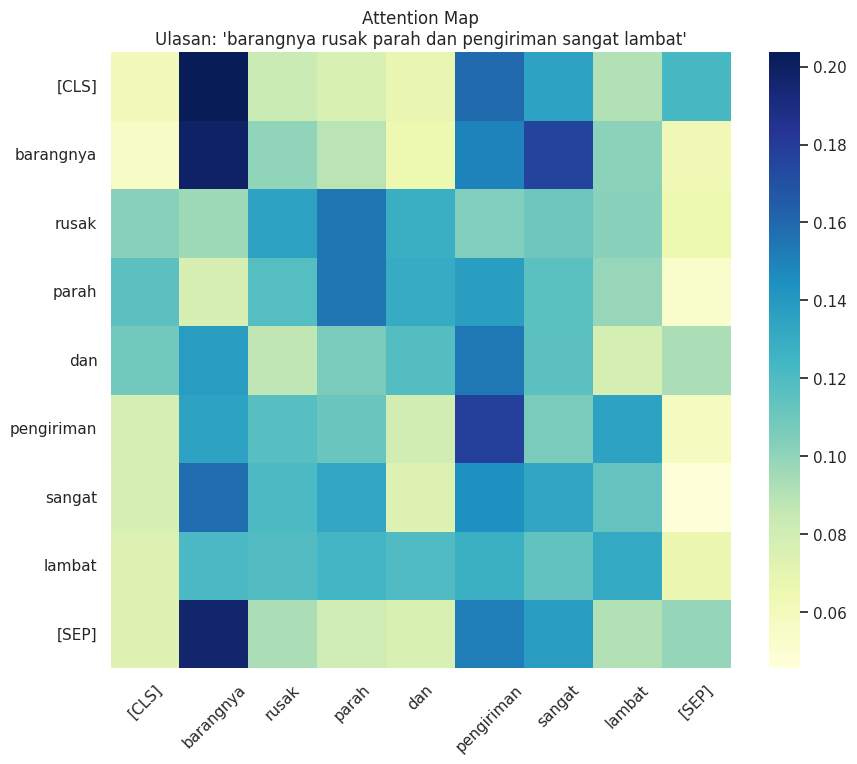

In [85]:
checkpoints = glob("results/checkpoint-*")
last_checkpoint = (
    max(checkpoints, key=os.path.getctime) if checkpoints else BERT_MODEL_NAME
)
print(f"Memuat model dari: {last_checkpoint}")

attention_model = AutoModelForSequenceClassification.from_pretrained(
    last_checkpoint,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
    attn_implementation="eager",
).to(trainer.args.device)


def visualize_attention(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128,
    ).to(attention_model.device)

    with torch.no_grad():
        outputs = attention_model(**inputs, output_attentions=True)

    attention = outputs.attentions[-1][0, 0].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        attention[: len(tokens), : len(tokens)],
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="YlGnBu",
    )
    plt.title(f"Attention Map\nUlasan: {text[:50]!r}")
    plt.xticks(rotation=45)
    plt.show()


sample_review = "barangnya rusak parah dan pengiriman sangat lambat"
visualize_attention(sample_review)


### 11.6 Perbandingan model


In [86]:
precision_smote, recall_smote, f1_smote, _ = precision_recall_fscore_support(
    y_test_s,
    y_pred_s,
    average="macro",
    zero_division=0,
)

comparison_data = {
    "Metrik": ["Accuracy", "Precision macro", "Recall macro", "F1-score macro"],
    "SMOTE (Logistic Regression)": [
        accuracy_score(y_test_s, y_pred_s),
        precision_smote,
        recall_smote,
        f1_smote,
    ],
    "IndoBERT": [
        bert_metrics["eval_accuracy"],
        bert_metrics["eval_precision"],
        bert_metrics["eval_recall"],
        bert_metrics["eval_f1"],
    ],
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison.set_index("Metrik").style.format("{:.2%}"))


,SMOTE (Logistic Regression),IndoBERT
Metrik,,
Accuracy,98.01%,72.62%
Precision macro,97.98%,73.27%
Recall macro,98.03%,72.62%
F1-score macro,97.99%,72.77%
